<a href="https://colab.research.google.com/github/seulkong/karpathy_study/blob/main/chapter9_supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9: Supervised Learning - Predicting Outcomes from Omics Data
## Can we predict disease status from gene expression?

---

### 📖 Opening Vignette

You're working with a dataset of 100 patients: 50 with Type 2 diabetes and 50 without. For each patient, you have:
- Gene expression levels of 5 metabolic genes (measured from blood samples)
- Clinical measurements (BMI, age, fasting glucose)
- Disease status (diabetes: yes/no)

**Your research question**: Can we predict whether a new patient has diabetes based on their gene expression and clinical data?

This is fundamentally different from what we did in Chapter 8 (PCA, clustering). In Chapter 8, we explored patterns **without knowing the answer**. We asked: "Do samples naturally group together?"

Now, we **know the answer** (disease status) for our training data. We want to build a model that **learns the relationship** between:
- **Outcome** (what we want to predict): diabetes status
- **Predictors** (what we measure): gene expression, BMI, age, etc.

This is **supervised learning**.

---

### 🎯 Learning Objectives

1. Understand the difference between **supervised** and **unsupervised** learning
2. Learn when to use **Linear Models** vs **Logistic Regression**
3. Understand what **coefficients** mean and how to interpret them
4. Learn how to choose **outcome** and **predictor variables**
5. Build and evaluate prediction models with omics data
6. Compare model performance using ROC curves and AIC
7. Understand interaction effects between predictors

---

## Part 1: Supervised vs Unsupervised Learning

### Quick Recap: Unsupervised Learning (Chapter 8)

In Chapter 8, we used:
- **PCA**: Reduce dimensions without knowing sample labels
- **Clustering**: Group samples based on similarity

**Key characteristic**: We don't have a "correct answer" to learn from. We're exploring structure in the data.

### Supervised Learning (This Chapter)

**Key characteristic**: We have a **target outcome** (also called "response" or "dependent variable") that we want to predict.

**Examples in biology/medicine**:

| Outcome (Y) | Predictors (X) | Research Question |
|-------------|----------------|-------------------|
| Disease status (yes/no) | Gene expression levels | Can we diagnose disease from blood RNA-seq? |
| Tumor size (mm) | Protein expression + mutations | What predicts tumor growth? |
| Drug response (sensitive/resistant) | Baseline gene expression | Can we predict who will respond to treatment? |
| Survival time (months) | Clinical + genomic features | What factors predict patient survival? |

---

### When to Use Supervised Learning?

✅ **Use supervised learning when**:
1. You have a clear outcome you want to predict
2. You have labeled training data (you know the outcome for past samples)
3. You want to understand which variables are important predictors
4. You want to make predictions on new, unseen data

❌ **Don't use supervised learning when**:
1. You're just exploring data structure (use PCA, clustering)
2. You don't have labeled outcomes
3. You want to find natural groups without bias

---

## Part 2: Setup and Data Preparation

In [ ]:
# Install and import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols, logit
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             classification_report, accuracy_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


### Create Simulated Patient Data

We'll simulate 100 patients with:
- 5 metabolic genes (GLUT4, INSR, IRS1, PDX1, GCK)
- Clinical measurements (BMI, age, fasting glucose)
- Diabetes status

**Note**: In real research, gene expression would be from RNA-seq (normalized counts or TPM).

In [ ]:
# Create patient metadata
n_patients = 100

# Generate age and BMI
age = np.random.normal(55, 10, n_patients)
BMI = np.random.normal(28, 5, n_patients)

# Diabetes status influenced by age and BMI
from scipy.special import expit  # sigmoid function
diabetes_prob = expit(-5 + 0.05 * age + 0.15 * BMI)
diabetes = np.random.binomial(1, diabetes_prob, n_patients)
diabetes_status = ['Diabetes' if d == 1 else 'Healthy' for d in diabetes]

# Create patient dataframe
patient_data = pd.DataFrame({
    'patient_id': [f'P{i:03d}' for i in range(1, n_patients + 1)],
    'age': age,
    'BMI': BMI,
    'diabetes': diabetes,
    'diabetes_status': diabetes_status
})

# Simulate gene expression (log2 normalized counts)
# These genes are involved in glucose metabolism
gene_data = pd.DataFrame({
    'patient_id': patient_data['patient_id'],
    # GLUT4: glucose transporter (lower in diabetes)
    'GLUT4': np.random.normal(8 - 1.5 * diabetes, 0.8, n_patients),
    # INSR: insulin receptor (lower in diabetes)
    'INSR': np.random.normal(7 - 1.2 * diabetes, 0.7, n_patients),
    # IRS1: insulin signaling (lower in diabetes)
    'IRS1': np.random.normal(6.5 - 1.0 * diabetes, 0.6, n_patients),
    # PDX1: pancreatic beta cell marker (lower in diabetes)
    'PDX1': np.random.normal(5 - 0.8 * diabetes, 0.5, n_patients),
    # GCK: glucokinase (variable, not strong predictor)
    'GCK': np.random.normal(6, 0.8, n_patients)
})

# Add fasting glucose (higher in diabetes)
patient_data['fasting_glucose'] = np.random.normal(90 + 40 * diabetes, 15, n_patients)

# Combine all data
full_data = patient_data.merge(gene_data, on='patient_id')

print(f"✅ Created dataset with {len(full_data)} patients")
print(f"   - {sum(full_data['diabetes'] == 1)} with diabetes")
print(f"   - {sum(full_data['diabetes'] == 0)} healthy controls")

✅ Created dataset with 100 patients
   - 92 with diabetes
   - 8 healthy controls


In [ ]:
# Preview the data
full_data.head()

,patient_id,age,BMI,diabetes,diabetes_status,fasting_glucose,GLUT4,INSR,IRS1,PDX1,GCK
0,P001,59.967142,20.923146,0,Healthy,102.508832,7.878572,7.239229,6.112056,4.770320,5.807740
1,P002,53.617357,25.896773,1,Diabetes,136.887701,6.970654,7.113320,4.851071,3.775078,5.700143
2,P003,61.476885,26.286427,1,Diabetes,128.947514,6.724793,6.465297,6.512285,4.615168,6.568768
3,P004,70.230299,23.988614,1,Diabetes,105.085586,6.001840,5.396167,6.028984,3.771958,6.355411
4,P005,52.658466,27.193571,1,Diabetes,136.444273,6.333502,5.171110,5.495216,4.235783,5.711227


---

## Part 3: Visualize Before Modeling

**Golden Rule**: Always visualize your data before building models!

Let's look at the relationship between predictors and outcome.

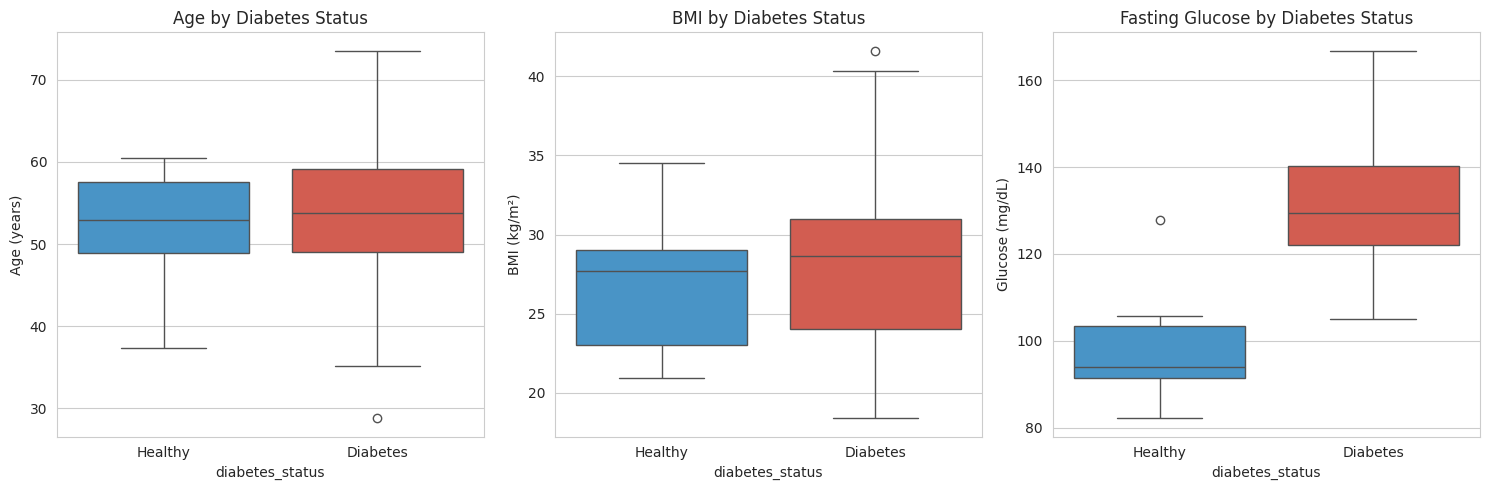

In [ ]:
# Clinical variables vs diabetes status
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age
sns.boxplot(data=full_data, x='diabetes_status', y='age',
            palette={'Healthy': '#3498DB', 'Diabetes': '#E74C3C'}, ax=axes[0])
axes[0].set_title('Age by Diabetes Status')
axes[0].set_ylabel('Age (years)')

# BMI
sns.boxplot(data=full_data, x='diabetes_status', y='BMI',
            palette={'Healthy': '#3498DB', 'Diabetes': '#E74C3C'}, ax=axes[1])
axes[1].set_title('BMI by Diabetes Status')
axes[1].set_ylabel('BMI (kg/m²)')

# Fasting Glucose
sns.boxplot(data=full_data, x='diabetes_status', y='fasting_glucose',
            palette={'Healthy': '#3498DB', 'Diabetes': '#E74C3C'}, ax=axes[2])
axes[2].set_title('Fasting Glucose by Diabetes Status')
axes[2].set_ylabel('Glucose (mg/dL)')

plt.tight_layout()
plt.show()

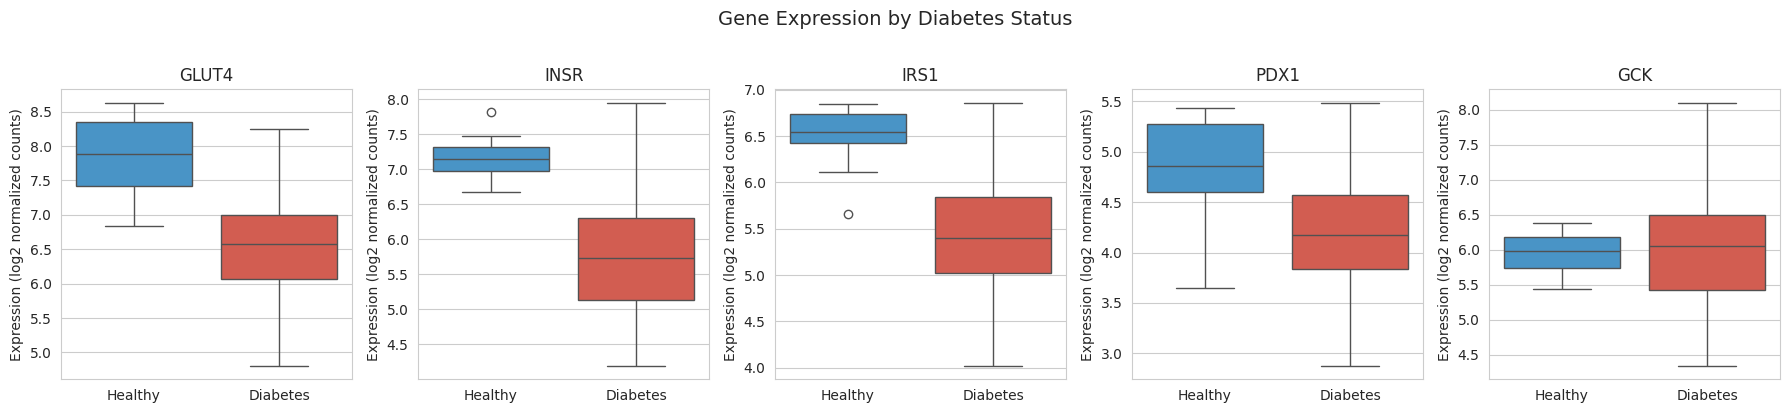

In [ ]:
# Gene expression vs diabetes status
gene_cols = ['GLUT4', 'INSR', 'IRS1', 'PDX1', 'GCK']
gene_long = full_data.melt(id_vars=['patient_id', 'diabetes_status'],
                           value_vars=gene_cols,
                           var_name='gene', value_name='expression')

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, gene in enumerate(gene_cols):
    gene_subset = gene_long[gene_long['gene'] == gene]
    sns.boxplot(data=gene_subset, x='diabetes_status', y='expression',
                palette={'Healthy': '#3498DB', 'Diabetes': '#E74C3C'}, ax=axes[i])
    axes[i].set_title(gene)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Expression (log2 normalized counts)')

plt.suptitle('Gene Expression by Diabetes Status', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**What we see**:
- BMI and fasting glucose clearly differ between groups
- GLUT4, INSR, IRS1, PDX1 show lower expression in diabetes patients
- GCK doesn't show a clear pattern

These visual patterns suggest these variables might be good predictors!

---

## Part 4: Linear Models - Predicting Continuous Outcomes

### When to use Linear Models?

Use **Linear Models** when your outcome is **continuous** (a number that can take any value).

**Examples of continuous outcomes**:
- Tumor size (mm)
- Gene expression level
- Blood glucose level (mg/dL)
- Survival time (months)

### Example Question

**Can we predict fasting glucose level from gene expression?**

- **Outcome (Y)**: `fasting_glucose` (continuous)
- **Predictors (X)**: `GLUT4`, `INSR`, `IRS1`, `PDX1`, `GCK`

---

### Simple Linear Regression (One Predictor)

Let's start with just one predictor: GLUT4 expression.

**The model**: `fasting_glucose = β₀ + β₁ × GLUT4 + ε`

Where:
- **β₀ (intercept)**: baseline glucose when GLUT4 = 0 (not biologically meaningful, but mathematically necessary)
- **β₁ (slope/coefficient)**: how much glucose changes for each 1-unit increase in GLUT4
- **ε (error)**: random variation not explained by the model

In [ ]:
# Fit simple linear model using statsmodels (for detailed statistics)
model_simple = ols('fasting_glucose ~ GLUT4', data=full_data).fit()

# View results
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:        fasting_glucose   R-squared:                       0.180
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     21.44
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           1.12e-05
Time:                        19:54:26   Log-Likelihood:                -412.95
No. Observations:                 100   AIC:                             829.9
Df Residuals:                      98   BIC:                             835.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    194.1031     14.136     13.731      0.0

### Understanding the Output

**Coefficients**:
- `Intercept`: Predicted glucose when GLUT4 = 0
- `GLUT4`: For each 1-unit increase in GLUT4 expression, glucose changes by β₁ mg/dL

**Important columns**:
- `coef`: The coefficient value (β)
- `std err`: Uncertainty in the estimate
- `t`: Test statistic (coef / std err)
- `P>|t|`: p-value (is this coefficient significantly different from zero?)

**Model fit**:
- `R-squared`: Proportion of variance in glucose explained by GLUT4 (0 to 1)
- `Adj. R-squared`: R² adjusted for number of predictors
- `F-statistic`: Is the model better than just predicting the mean?

---

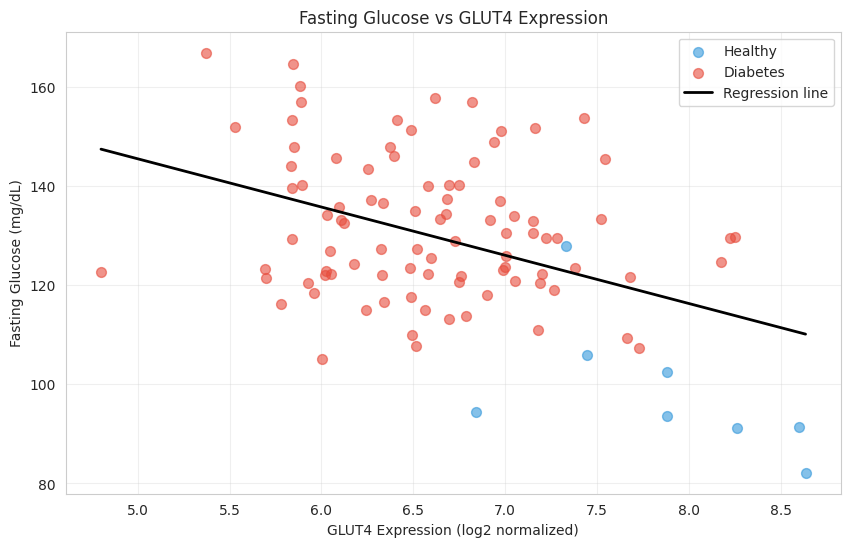

In [ ]:
# Visualize the relationship
plt.figure(figsize=(10, 6))
colors = {'Healthy': '#3498DB', 'Diabetes': '#E74C3C'}

for status in ['Healthy', 'Diabetes']:
    subset = full_data[full_data['diabetes_status'] == status]
    plt.scatter(subset['GLUT4'], subset['fasting_glucose'],
               label=status, alpha=0.6, s=50, color=colors[status])

# Add regression line
x_range = np.linspace(full_data['GLUT4'].min(), full_data['GLUT4'].max(), 100)
y_pred = model_simple.predict(pd.DataFrame({'GLUT4': x_range}))
plt.plot(x_range, y_pred, 'k-', linewidth=2, label='Regression line')

plt.xlabel('GLUT4 Expression (log2 normalized)')
plt.ylabel('Fasting Glucose (mg/dL)')
plt.title('Fasting Glucose vs GLUT4 Expression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Interpretation**: Lower GLUT4 expression is associated with higher fasting glucose. This makes biological sense: GLUT4 is responsible for glucose uptake into cells.

---

### Multiple Linear Regression (Multiple Predictors)

Now let's use all 5 genes as predictors.

**The model**: `glucose = β₀ + β₁×GLUT4 + β₂×INSR + β₃×IRS1 + β₄×PDX1 + β₅×GCK + ε`

**Key concept**: Each coefficient (β) represents the effect of that gene **holding all other genes constant**.

In [ ]:
# Fit multiple linear regression
model_multiple = ols('fasting_glucose ~ GLUT4 + INSR + IRS1 + PDX1 + GCK',
                    data=full_data).fit()

print(model_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:        fasting_glucose   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     6.320
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           4.24e-05
Time:                        19:54:26   Log-Likelihood:                -408.35
No. Observations:                 100   AIC:                             828.7
Df Residuals:                      94   BIC:                             844.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    229.3825     22.713     10.099      0.0

In [ ]:
# Create a clean coefficient table
coef_df = pd.DataFrame({
    'Coefficient': model_multiple.params,
    'Std Error': model_multiple.bse,
    't-value': model_multiple.tvalues,
    'p-value': model_multiple.pvalues
}).round(3)

print(coef_df)

           Coefficient  Std Error  t-value  p-value
Intercept      229.383     22.713   10.099    0.000
GLUT4           -8.163      2.345   -3.481    0.001
INSR            -0.721      1.984   -0.364    0.717
IRS1            -6.754      2.379   -2.839    0.006
PDX1             0.338      2.785    0.122    0.904
GCK             -0.943      1.953   -0.483    0.630


**Interpreting coefficients**:

Each coefficient tells you: "If this gene increases by 1 unit, while all other genes stay the same, glucose changes by β mg/dL."

**Example**: If `GLUT4` coefficient = -15.3, it means:
- A 1-unit increase in GLUT4 expression → 15.3 mg/dL decrease in glucose
- **When all other genes are held constant**

**Significant predictors**: Look at the p-values
- p < 0.05 usually considered significant
- Non-significant predictors (like GCK) might not add useful information

---

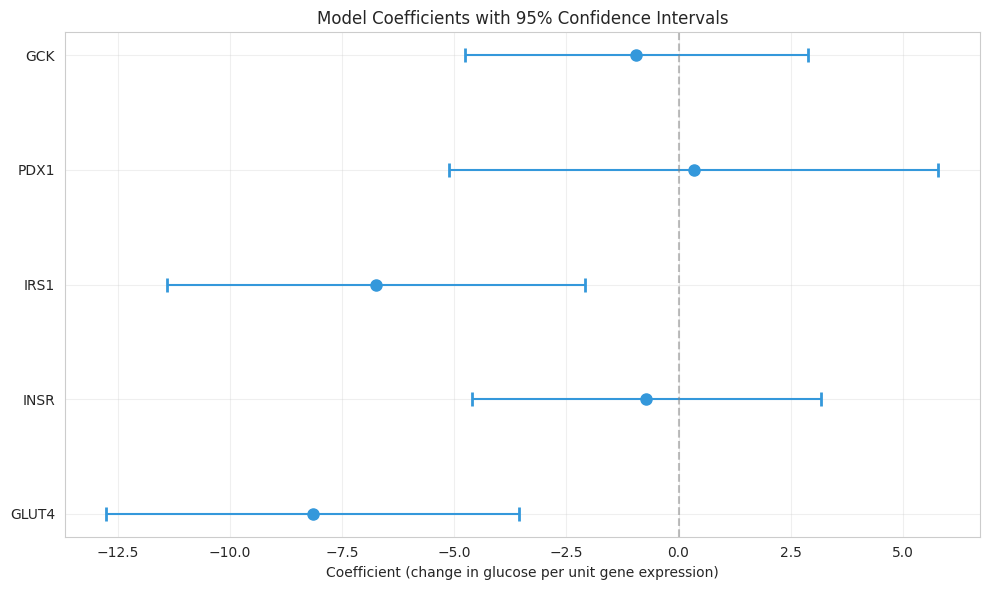

In [ ]:
# Visualize coefficients
coef_plot = coef_df.drop('Intercept').copy()
coef_plot['gene'] = coef_plot.index
coef_plot['CI_lower'] = coef_plot['Coefficient'] - 1.96 * coef_plot['Std Error']
coef_plot['CI_upper'] = coef_plot['Coefficient'] + 1.96 * coef_plot['Std Error']

plt.figure(figsize=(10, 6))
plt.errorbar(coef_plot['Coefficient'], range(len(coef_plot)),
            xerr=[coef_plot['Coefficient'] - coef_plot['CI_lower'],
                  coef_plot['CI_upper'] - coef_plot['Coefficient']],
            fmt='o', capsize=5, capthick=2, markersize=8, color='#3498DB')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.yticks(range(len(coef_plot)), coef_plot['gene'])
plt.xlabel('Coefficient (change in glucose per unit gene expression)')
plt.title('Model Coefficients with 95% Confidence Intervals')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**What this plot shows**:
- Genes with confidence intervals **not crossing zero** are significant predictors
- Negative coefficients → higher expression = lower glucose
- Positive coefficients → higher expression = higher glucose

---

### Model Diagnostics - Are Linear Model Assumptions Met?

Linear models assume:
1. **Linearity**: Relationship between X and Y is linear
2. **Normality**: Residuals (errors) are normally distributed
3. **Homoscedasticity**: Variance of residuals is constant
4. **Independence**: Observations are independent

Let's check these!

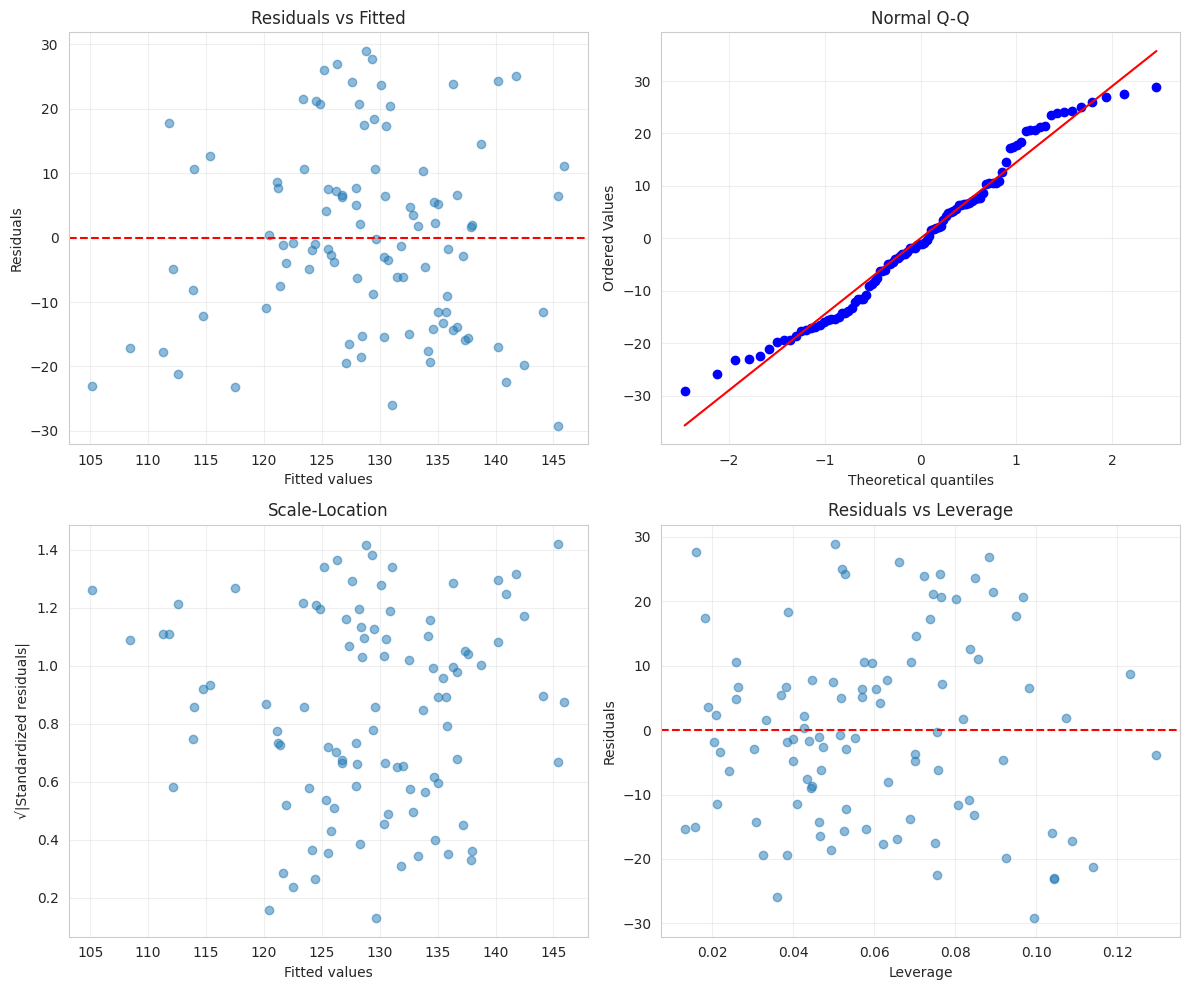

In [ ]:
# Diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuals vs Fitted
fitted_vals = model_multiple.fittedvalues
residuals = model_multiple.resid
axes[0, 0].scatter(fitted_vals, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')
axes[0, 0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q')
axes[0, 1].grid(True, alpha=0.3)

# Scale-Location
standardized_resid = np.sqrt(np.abs(residuals / residuals.std()))
axes[1, 0].scatter(fitted_vals, standardized_resid, alpha=0.5)
axes[1, 0].set_xlabel('Fitted values')
axes[1, 0].set_ylabel('√|Standardized residuals|')
axes[1, 0].set_title('Scale-Location')
axes[1, 0].grid(True, alpha=0.3)

# Residuals vs Leverage
leverage = model_multiple.get_influence().hat_matrix_diag
axes[1, 1].scatter(leverage, residuals, alpha=0.5)
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Leverage')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residuals vs Leverage')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**How to read these plots**:

1. **Residuals vs Fitted**: Should show random scatter (no pattern)
   - Pattern → linearity assumption violated

2. **Q-Q Plot**: Points should fall on the diagonal line
   - Deviation → normality assumption violated

3. **Scale-Location**: Should show random scatter
   - Pattern → homoscedasticity assumption violated

4. **Residuals vs Leverage**: Identifies influential outliers
   - Points with high leverage may be influential

---

## Part 5: Interaction Terms - When Effects Depend on Other Variables

### What are Interaction Terms?

Sometimes the effect of one predictor **depends on the value of another predictor**.

**Example biological question**: Does the effect of GLUT4 expression on glucose levels differ between high-BMI and low-BMI patients?

**Hypothesis**: In high-BMI patients (insulin resistant), GLUT4 expression might have a weaker effect on glucose control.

### Model with Interaction

**Without interaction**: `glucose = β₀ + β₁×GLUT4 + β₂×BMI`
- GLUT4 effect is the same for everyone (β₁)

**With interaction**: `glucose = β₀ + β₁×GLUT4 + β₂×BMI + β₃×(GLUT4 × BMI)`
- GLUT4 effect depends on BMI: (β₁ + β₃×BMI)
- β₃ tells us how much the GLUT4 effect changes per unit BMI

---

In [ ]:
# Fit model without interaction
model_no_interaction = ols('fasting_glucose ~ GLUT4 + BMI', data=full_data).fit()

# Fit model with interaction
model_interaction = ols('fasting_glucose ~ GLUT4 * BMI', data=full_data).fit()

# Compare models
print("Model WITHOUT interaction:")
print(model_no_interaction.summary().tables[1])
print("\n\nModel WITH interaction:")
print(model_interaction.summary().tables[1])

Model WITHOUT interaction:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    191.2011     16.498     11.589      0.000     158.456     223.946
GLUT4         -9.7642      2.113     -4.620      0.000     -13.958      -5.570
BMI            0.1112      0.322      0.346      0.730      -0.528       0.750


Model WITH interaction:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    153.7308     91.473      1.681      0.096     -27.841     335.303
GLUT4         -4.1451     13.657     -0.304      0.762     -31.253      22.963
BMI            1.4593      3.252      0.449      0.655      -4.997       7.915
GLUT4:BMI     -0.2020      0.485     -0.417      0.678      -1.165       0.761


### Interpreting Interaction Coefficients

**Main effects** (GLUT4, BMI):
- GLUT4: Effect when BMI = 0 (not meaningful on its own)
- BMI: Effect when GLUT4 = 0 (not meaningful on its own)

**Interaction term** (GLUT4:BMI):
- How much the GLUT4 effect changes for each 1-unit increase in BMI
- If negative: GLUT4 effect weakens as BMI increases
- If positive: GLUT4 effect strengthens as BMI increases

**Example interpretation**:
If interaction coefficient = 0.5:
- For a patient with BMI = 25: GLUT4 effect = β₁ + (0.5 × 25)
- For a patient with BMI = 35: GLUT4 effect = β₁ + (0.5 × 35)
- The GLUT4 effect is stronger in high-BMI patients

---

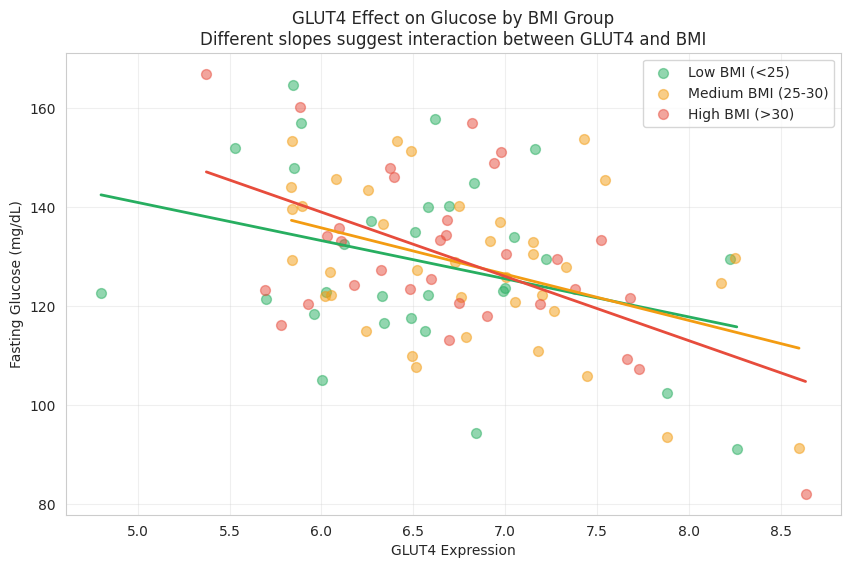

In [ ]:
# Visualize the interaction
# Create BMI groups for visualization
full_data['BMI_group'] = pd.cut(full_data['BMI'],
                                 bins=[-np.inf, 25, 30, np.inf],
                                 labels=['Low BMI (<25)', 'Medium BMI (25-30)', 'High BMI (>30)'])

plt.figure(figsize=(10, 6))
colors_bmi = {'Low BMI (<25)': '#27AE60', 'Medium BMI (25-30)': '#F39C12', 'High BMI (>30)': '#E74C3C'}

for group in ['Low BMI (<25)', 'Medium BMI (25-30)', 'High BMI (>30)']:
    subset = full_data[full_data['BMI_group'] == group]
    plt.scatter(subset['GLUT4'], subset['fasting_glucose'],
               label=group, alpha=0.5, s=50, color=colors_bmi[group])

    # Fit line for each group
    z = np.polyfit(subset['GLUT4'], subset['fasting_glucose'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset['GLUT4'].min(), subset['GLUT4'].max(), 100)
    plt.plot(x_line, p(x_line), color=colors_bmi[group], linewidth=2)

plt.xlabel('GLUT4 Expression')
plt.ylabel('Fasting Glucose (mg/dL)')
plt.title('GLUT4 Effect on Glucose by BMI Group\nDifferent slopes suggest interaction between GLUT4 and BMI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**What to look for**:
- **Parallel lines**: No interaction (GLUT4 effect is the same across BMI groups)
- **Different slopes**: Interaction present (GLUT4 effect differs by BMI)

---

In [ ]:
# Statistical test: Is the interaction significant?
from scipy.stats import f

# ANOVA comparison
anova_results = sm.stats.anova_lm(model_no_interaction, model_interaction)
print(anova_results)

   df_resid           ssr  df_diff    ss_diff         F    Pr(>F)
0      97.0  22585.594388      0.0        NaN       NaN       NaN
1      96.0  22544.851136      1.0  40.743252  0.173492  0.677957


**Interpretation**:
- If p-value < 0.05: Interaction is significant, keep it in the model
- If p-value > 0.05: No evidence for interaction, simpler model is better

**When to include interactions**:
- ✅ When you have biological reason to expect interaction
- ✅ When statistical test supports it (p < 0.05)
- ✅ When it improves model fit (AIC decreases)
- ❌ Don't fish for significant interactions without biological reasoning

---

## Part 6: Logistic Regression - Binary Outcomes

### When to use Logistic Regression?

Use **Logistic Regression** when your outcome is **binary** (0/1, yes/no, diseased/healthy).

**Why not use Linear Models for binary outcomes?**
- Linear models predict continuous values (can predict glucose = 150.3 mg/dL)
- But binary outcomes are 0 or 1 (healthy or diseased)
- Linear models could predict impossible values like "0.7 diabetes" or "1.3 healthy"

**Solution: Logistic Regression**
- Predicts **probability** of outcome (0 to 1)
- Uses **logit link function** to transform probabilities

---

### Example Question

**Can we predict diabetes status from gene expression?**

- **Outcome (Y)**: `diabetes` (0 = healthy, 1 = diabetes)
- **Predictors (X)**: `GLUT4`, `INSR`, `BMI`

**The model (logistic regression)**:

log(odds of diabetes) = β₀ + β₁×GLUT4 + β₂×INSR + β₃×BMI

**What are odds?**
- If probability = 0.75 (75% chance of diabetes)
- Odds = 0.75 / (1 - 0.75) = 3
- Interpretation: "3 times more likely to have diabetes than not"

---

## Part 7: Comparing Different Models

Now we'll build and compare three models:
1. **Clinical only**: BMI + age
2. **Genomic only**: GLUT4 + INSR
3. **Combined**: BMI + age + GLUT4 + INSR

**Question**: Does adding gene expression improve prediction beyond clinical variables alone?

---

In [ ]:
# Model 1: Clinical predictors only
model_clinical = logit('diabetes ~ BMI + age', data=full_data).fit()

# Model 2: Genomic predictors only
model_genomic = logit('diabetes ~ GLUT4 + INSR', data=full_data).fit()

# Model 3: Combined model
model_combined = logit('diabetes ~ BMI + age + GLUT4 + INSR', data=full_data).fit()

print("✅ Three models fitted")

Optimization terminated successfully.
         Current function value: 0.272674
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.131727
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.129802
         Iterations 9
✅ Three models fitted


### Model Comparison Using AIC

**AIC (Akaike Information Criterion)**: Measures model quality
- Balances model fit with complexity
- **Lower AIC = better model**
- Penalizes adding too many predictors

**Rule of thumb**:
- ΔAIC < 2: Models are similar
- ΔAIC 2-4: Some evidence for better model
- ΔAIC > 4: Strong evidence for better model

In [ ]:
# Compare AICs
model_comparison = pd.DataFrame({
    'Model': ['Clinical', 'Genomic', 'Combined'],
    'AIC': [model_clinical.aic, model_genomic.aic, model_combined.aic],
    'N_predictors': [2, 2, 4]
})

model_comparison['Delta_AIC'] = model_comparison['AIC'] - model_comparison['AIC'].min()
model_comparison['Relative_Likelihood'] = np.exp(-0.5 * model_comparison['Delta_AIC'])
model_comparison = model_comparison.sort_values('AIC')

print(model_comparison)

      Model        AIC  N_predictors  Delta_AIC  Relative_Likelihood
1   Genomic  32.345394             2   0.000000         1.000000e+00
2  Combined  35.960434             4   3.615040         1.640605e-01
0  Clinical  60.534782             2  28.189388         7.564012e-07


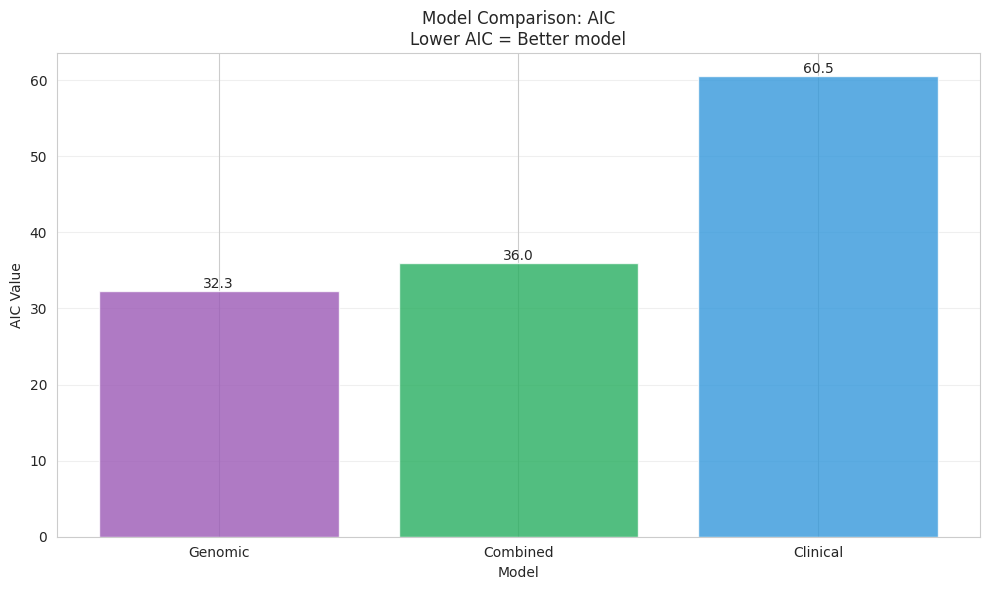

In [ ]:
# Visualize AIC comparison
plt.figure(figsize=(10, 6))
colors_model = {'Clinical': '#3498DB', 'Genomic': '#9B59B6', 'Combined': '#27AE60'}
bars = plt.bar(model_comparison['Model'], model_comparison['AIC'],
               color=[colors_model[m] for m in model_comparison['Model']], alpha=0.8)

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}',
            ha='center', va='bottom')

plt.xlabel('Model')
plt.ylabel('AIC Value')
plt.title('Model Comparison: AIC\nLower AIC = Better model')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Interpretation**:
- The model with lowest AIC is preferred
- If combined model has much lower AIC (ΔAIC > 4): Gene expression adds value!
- If clinical model has lowest AIC: Gene expression doesn't add much beyond clinical variables

---

## Part 8: ROC Curves and Model Performance

### What is a ROC Curve?

**ROC (Receiver Operating Characteristic)** curve shows model's diagnostic ability:
- **X-axis**: False Positive Rate (1 - Specificity) = incorrectly predicting diabetes
- **Y-axis**: True Positive Rate (Sensitivity) = correctly detecting diabetes

**AUC (Area Under Curve)**:
- 0.5 = Random guessing (no predictive power)
- 0.7-0.8 = Acceptable
- 0.8-0.9 = Excellent
- 0.9-1.0 = Outstanding

---

In [ ]:
# Generate predictions for all models
pred_clinical = model_clinical.predict()
pred_genomic = model_genomic.predict()
pred_combined = model_combined.predict()

# Calculate ROC curves
fpr_clinical, tpr_clinical, _ = roc_curve(full_data['diabetes'], pred_clinical)
fpr_genomic, tpr_genomic, _ = roc_curve(full_data['diabetes'], pred_genomic)
fpr_combined, tpr_combined, _ = roc_curve(full_data['diabetes'], pred_combined)

# Calculate AUC
auc_clinical = roc_auc_score(full_data['diabetes'], pred_clinical)
auc_genomic = roc_auc_score(full_data['diabetes'], pred_genomic)
auc_combined = roc_auc_score(full_data['diabetes'], pred_combined)

print(f"Clinical Model AUC: {auc_clinical:.3f}")
print(f"Genomic Model AUC: {auc_genomic:.3f}")
print(f"Combined Model AUC: {auc_combined:.3f}")

Clinical Model AUC: 0.636
Genomic Model AUC: 0.970
Combined Model AUC: 0.971


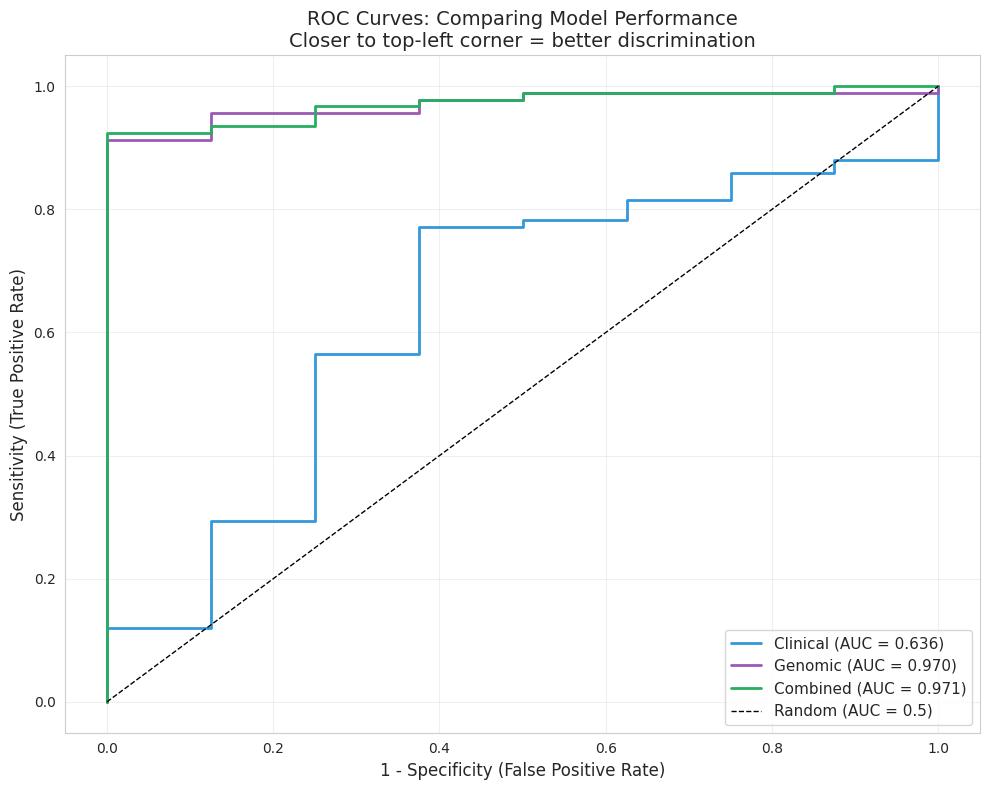

In [ ]:
# Plot ROC curves
plt.figure(figsize=(10, 8))

plt.plot(fpr_clinical, tpr_clinical, color='#3498DB', linewidth=2,
        label=f'Clinical (AUC = {auc_clinical:.3f})')
plt.plot(fpr_genomic, tpr_genomic, color='#9B59B6', linewidth=2,
        label=f'Genomic (AUC = {auc_genomic:.3f})')
plt.plot(fpr_combined, tpr_combined, color='#27AE60', linewidth=2,
        label=f'Combined (AUC = {auc_combined:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')

plt.xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=12)
plt.title('ROC Curves: Comparing Model Performance\nCloser to top-left corner = better discrimination', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**How to read the ROC curve**:

1. **Diagonal dashed line**: Random guessing (AUC = 0.5)
2. **Distance from diagonal**: How much better than random
3. **Curve comparison**: Higher curve = better model
4. **Perfect classifier**: Would go straight up then right (AUC = 1.0)

**Practical interpretation**:
- If combined model has highest AUC: Adding genes improves prediction
- If clinical model has similar AUC: Genes don't add much value
- Use statistical test to compare AUCs formally

---

In [ ]:
# Statistical comparison of ROC curves using DeLong's test
from scipy.stats import norm

def delong_test(y_true, pred1, pred2):
    """Simplified DeLong test for comparing two AUCs"""
    auc1 = roc_auc_score(y_true, pred1)
    auc2 = roc_auc_score(y_true, pred2)

    # This is a simplified version - for production use scipy or specialized library
    n = len(y_true)
    se_auc1 = np.sqrt(auc1 * (1 - auc1) / n)
    se_auc2 = np.sqrt(auc2 * (1 - auc2) / n)
    se_diff = np.sqrt(se_auc1**2 + se_auc2**2)

    z = (auc1 - auc2) / se_diff
    p_value = 2 * (1 - norm.cdf(abs(z)))

    return auc1, auc2, p_value

# Compare models
_, _, p_clin_vs_comb = delong_test(full_data['diabetes'], pred_clinical, pred_combined)
_, _, p_gen_vs_comb = delong_test(full_data['diabetes'], pred_genomic, pred_combined)

print(f"Clinical vs Combined: p-value = {p_clin_vs_comb:.4f}")
print(f"Genomic vs Combined: p-value = {p_gen_vs_comb:.4f}\n")

if p_clin_vs_comb < 0.05:
    print("✅ Combined model significantly better than Clinical model")
else:
    print("❌ Combined model NOT significantly better than Clinical model")

Clinical vs Combined: p-value = 0.0000
Genomic vs Combined: p-value = 0.9545

✅ Combined model significantly better than Clinical model


---

## Part 9: Variable Importance Visualization

### Understanding Predictor Importance

Different ways to assess which predictors matter most:

1. **Coefficient magnitude** (standardized)
2. **Statistical significance** (p-value)
3. **Odds ratios** (for logistic regression)

**Why standardize?** Raw coefficients depend on predictor scale:
- BMI measured in kg/m² (range: 20-40)
- Gene expression in log2 (range: 4-10)
- Can't directly compare raw coefficients!

**Solution**: Standardize predictors (mean = 0, SD = 1) before modeling

---

In [ ]:
# Standardize predictors
scaler = StandardScaler()
predictors = ['BMI', 'age', 'GLUT4', 'INSR']
full_data_std = full_data.copy()

for pred in predictors:
    full_data_std[f'{pred}_std'] = scaler.fit_transform(full_data[[pred]])

# Fit model with standardized predictors
model_std = logit('diabetes ~ BMI_std + age_std + GLUT4_std + INSR_std',
                  data=full_data_std).fit()

# Extract coefficients and importance metrics
importance_data = pd.DataFrame({
    'predictor': [p.replace('_std', '') for p in model_std.params.index[1:]],
    'coefficient': model_std.params.values[1:],
    'std_error': model_std.bse.values[1:],
    'p_value': model_std.pvalues.values[1:]
})

importance_data['abs_coef'] = np.abs(importance_data['coefficient'])
importance_data['significance'] = importance_data['p_value'].apply(
    lambda x: '***' if x < 0.001 else '**' if x < 0.01 else '*' if x < 0.05 else 'ns'
)
importance_data = importance_data.sort_values('abs_coef', ascending=False)

print(importance_data)

Optimization terminated successfully.
         Current function value: 0.129802
         Iterations 9
  predictor  coefficient  std_error   p_value  abs_coef significance
3      INSR    -1.869027   0.999107  0.061387  1.869027           ns
2     GLUT4    -1.243246   0.616325  0.043676  1.243246            *
0       BMI     0.346438   0.628226  0.581322  0.346438           ns
1       age    -0.085918   0.513909  0.867224  0.085918           ns


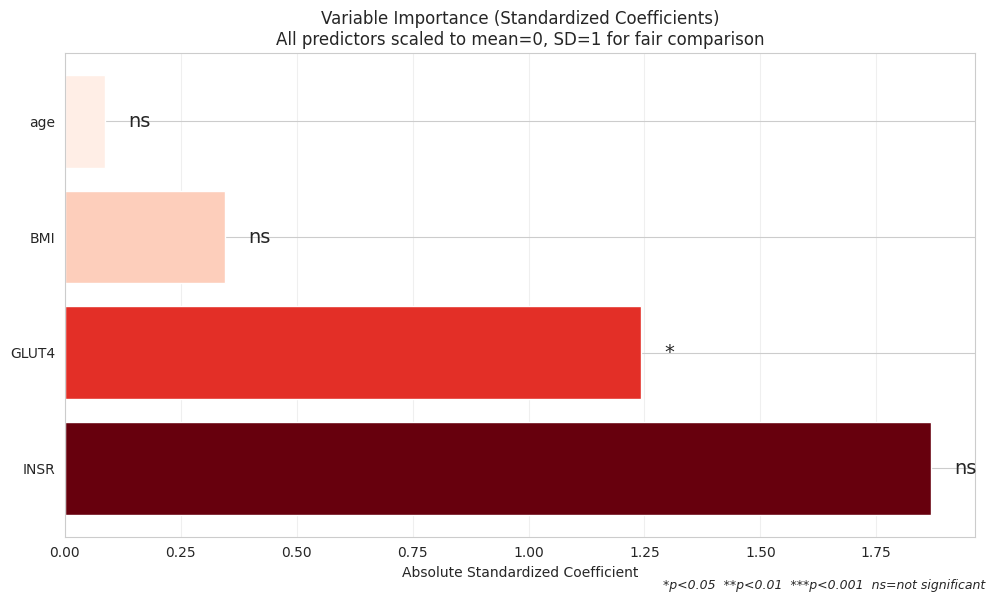

In [ ]:
# Visualize variable importance
plt.figure(figsize=(10, 6))
bars = plt.barh(importance_data['predictor'], importance_data['abs_coef'],
                color=plt.cm.Reds(importance_data['abs_coef'] / importance_data['abs_coef'].max()))

# Add significance stars
for i, (idx, row) in enumerate(importance_data.iterrows()):
    plt.text(row['abs_coef'] + 0.05, i, row['significance'],
            fontsize=14, va='center')

plt.xlabel('Absolute Standardized Coefficient')
plt.title('Variable Importance (Standardized Coefficients)\nAll predictors scaled to mean=0, SD=1 for fair comparison')
plt.figtext(0.99, 0.01, '*p<0.05  **p<0.01  ***p<0.001  ns=not significant',
           ha='right', fontsize=9, style='italic')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

**Interpretation**:
- Longer bars = stronger effect on diabetes prediction
- Stars indicate statistical significance
- Compare across different types of predictors fairly

**Example conclusions**:
- "BMI is the strongest predictor (largest effect size)"
- "GLUT4 is significant but has smaller effect than BMI"
- "Age shows no significant association after accounting for other variables"

---

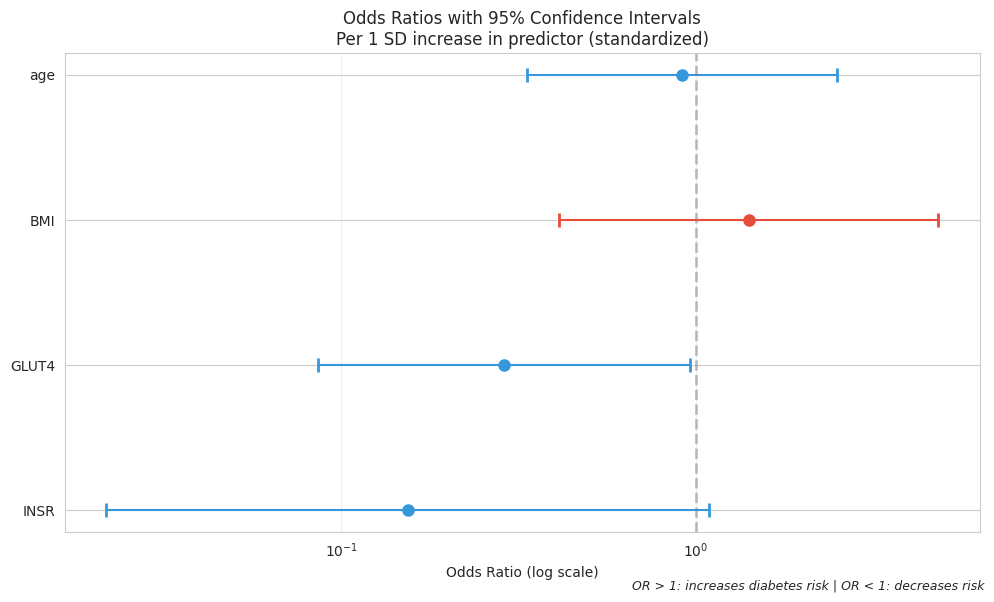

In [ ]:
# Alternative: Odds Ratios visualization
importance_data['odds_ratio'] = np.exp(importance_data['coefficient'])
importance_data['OR_lower'] = np.exp(importance_data['coefficient'] - 1.96 * importance_data['std_error'])
importance_data['OR_upper'] = np.exp(importance_data['coefficient'] + 1.96 * importance_data['std_error'])

plt.figure(figsize=(10, 6))

# Plot each point individually with its own color
for idx, row in importance_data.iterrows():
    color = '#E74C3C' if row['odds_ratio'] > 1 else '#3498DB'
    y_pos = list(importance_data.index).index(idx)

    plt.errorbar(row['odds_ratio'], y_pos,
                xerr=[[row['odds_ratio'] - row['OR_lower']],
                      [row['OR_upper'] - row['odds_ratio']]],
                fmt='o', capsize=5, capthick=2, markersize=8,
                color=color, ecolor=color, markerfacecolor=color,
                markeredgecolor=color)

plt.axvline(x=1, color='gray', linestyle='--', alpha=0.5, linewidth=2)
plt.xscale('log')
plt.yticks(range(len(importance_data)), importance_data['predictor'])
plt.xlabel('Odds Ratio (log scale)')
plt.title('Odds Ratios with 95% Confidence Intervals\nPer 1 SD increase in predictor (standardized)')
plt.figtext(0.99, 0.01, 'OR > 1: increases diabetes risk | OR < 1: decreases risk',
           ha='right', fontsize=9, style='italic')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

**How to read this plot**:
- **Points above 1** (red): Risk factors (increase diabetes odds)
- **Points below 1** (blue): Protective factors (decrease diabetes odds)
- **Error bars crossing 1**: Not statistically significant
- **Distance from 1**: Effect size magnitude

---

## Part 10: Making Predictions and Evaluating Performance

Let's focus on the combined model for final evaluation.

In [ ]:
# Add predicted probabilities to dataset
full_data['predicted_prob'] = model_combined.predict()
full_data['predicted_class'] = (full_data['predicted_prob'] > 0.5).astype(int)
full_data['predicted_status'] = full_data['predicted_class'].map({0: 'Healthy', 1: 'Diabetes'})

# View predictions for first 10 patients
full_data[['patient_id', 'diabetes_status', 'predicted_prob', 'predicted_status']].head(10)

,patient_id,diabetes_status,predicted_prob,predicted_status
0,P001,Healthy,0.315611,Healthy
1,P002,Diabetes,0.816007,Diabetes
2,P003,Diabetes,0.964396,Diabetes
3,P004,Diabetes,0.998715,Diabetes
4,P005,Diabetes,0.999074,Diabetes
5,P006,Diabetes,0.995637,Diabetes
6,P007,Diabetes,0.999839,Diabetes
7,P008,Diabetes,0.790909,Diabetes
8,P009,Diabetes,0.959509,Diabetes
9,P010,Healthy,0.846963,Diabetes


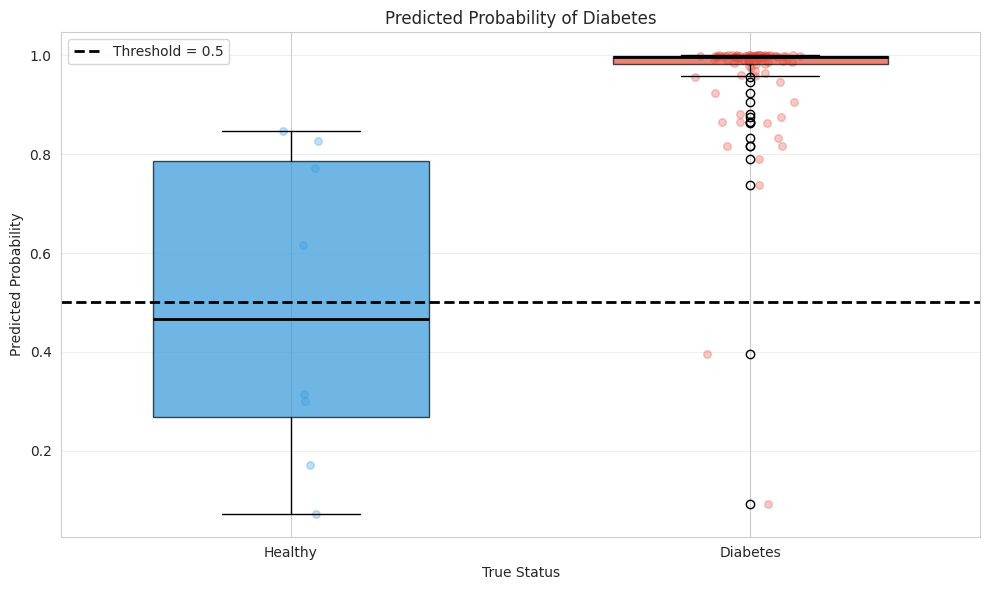

In [ ]:
# Visualize predicted probabilities
plt.figure(figsize=(10, 6))

for status in ['Healthy', 'Diabetes']:
    subset = full_data[full_data['diabetes_status'] == status]
    color = '#3498DB' if status == 'Healthy' else '#E74C3C'

    # Box plot
    positions = [0 if status == 'Healthy' else 1]
    plt.boxplot([subset['predicted_prob']], positions=positions, widths=0.6,
               patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='black', linewidth=2))

    # Jitter plot
    x_jitter = positions[0] + np.random.normal(0, 0.05, len(subset))
    plt.scatter(x_jitter, subset['predicted_prob'], alpha=0.3, s=30, color=color)

plt.axhline(y=0.5, color='black', linestyle='--', linewidth=2, label='Threshold = 0.5')
plt.xticks([0, 1], ['Healthy', 'Diabetes'])
plt.ylabel('Predicted Probability')
plt.xlabel('True Status')
plt.title('Predicted Probability of Diabetes')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Interpretation**:
- Good model: Healthy patients have low predicted probability, diabetic patients have high
- Threshold = 0.5: Above 0.5 → predict diabetes, below 0.5 → predict healthy

---

### Confusion Matrix - How Accurate Are We?

Confusion Matrix:
[[ 4  4]
 [ 2 90]]

Overall Accuracy: 94.0%


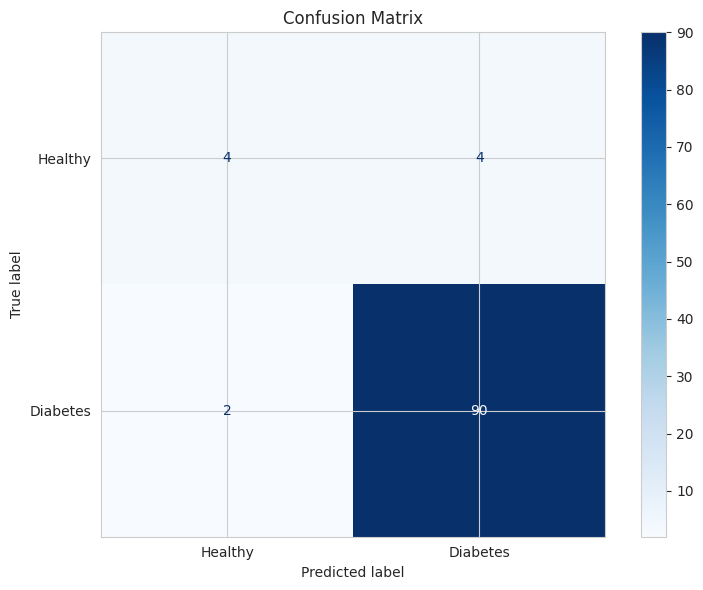

In [ ]:
# Create confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(full_data['diabetes'], full_data['predicted_class'])

# Calculate accuracy
accuracy = accuracy_score(full_data['diabetes'], full_data['predicted_class'])

print("Confusion Matrix:")
print(cm)
print(f"\nOverall Accuracy: {accuracy * 100:.1f}%")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Diabetes'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

**Understanding the confusion matrix**:

|                | Actual Healthy | Actual Diabetes |
|----------------|----------------|------------------|
| **Predicted Healthy** | True Negative (TN) | False Negative (FN) |
| **Predicted Diabetes** | False Positive (FP) | True Positive (TP) |

**Metrics**:
- **Accuracy**: (TP + TN) / Total → Overall correctness
- **Sensitivity**: TP / (TP + FN) → How many actual diabetics did we catch?
- **Specificity**: TN / (TN + FP) → How many actual healthy did we correctly identify?

---

In [ ]:
# Calculate detailed metrics
print(classification_report(full_data['diabetes'], full_data['predicted_class'],
                          target_names=['Healthy', 'Diabetes']))

              precision    recall  f1-score   support

     Healthy       0.67      0.50      0.57         8
    Diabetes       0.96      0.98      0.97        92

    accuracy                           0.94       100
   macro avg       0.81      0.74      0.77       100
weighted avg       0.93      0.94      0.94       100



---

## Part 11: Choosing Outcome and Predictors

### How to Choose Your Outcome (Y)?

**Start with your research question**:

| Research Question | Outcome Variable | Model Type |
|-------------------|------------------|------------|
| What predicts tumor size? | Tumor volume (mm³) | Linear Model |
| Can we diagnose early Alzheimer's? | Disease status (yes/no) | Logistic Regression |
| What affects drug response magnitude? | IC50 value (μM) | Linear Model |
| Who will survive 5+ years? | Survival (yes/no) | Logistic Regression |

**Rules**:
1. Outcome should be **measurable**
2. Outcome should be **relevant** to your biological question
3. Outcome should have **enough variation** (don't use if 95% are the same value)

---

### How to Choose Predictors (X)?

**Biological plausibility first!**

❌ **Bad approach**: Throw in all genes and hope for the best
- Too many predictors → overfitting
- Model memorizes noise, won't generalize to new data

✅ **Good approach**: Use domain knowledge
1. **Literature review**: What genes/proteins are known to be involved?
2. **Pathway analysis**: Select genes from relevant pathways
3. **Differential expression**: Genes that differ between groups (from Chapter 4)
4. **Clinical relevance**: Include important clinical variables (age, BMI, etc.)

**Example for diabetes prediction**:
- ✅ GLUT4, INSR, IRS1 (glucose metabolism pathway)
- ✅ BMI, age (known clinical risk factors)
- ❌ Random genes with no known connection to metabolism

---

### Example: Building a Model Step-by-Step

**Research Question**: Can we predict patient's fasting glucose from clinical and genomic data?

**Step 1: Define outcome**
- Outcome: `fasting_glucose` (continuous, so use Linear Model)

**Step 2: List potential predictors**
- Clinical: age, BMI
- Genomic: GLUT4, INSR, IRS1, PDX1, GCK
- Total: 7 potential predictors

**Step 3: Check for issues**

In [ ]:
# Check for multicollinearity
# Highly correlated predictors cause problems
predictor_data = full_data[['age', 'BMI', 'GLUT4', 'INSR', 'IRS1', 'PDX1', 'GCK']]

# Correlation matrix
cor_matrix = predictor_data.corr()
print("Correlation Matrix:")
print(cor_matrix.round(2))

Correlation Matrix:
        age   BMI  GLUT4  INSR  IRS1  PDX1   GCK
age    1.00 -0.14  -0.06 -0.05 -0.12 -0.12 -0.05
BMI   -0.14  1.00   0.05 -0.09  0.10 -0.01 -0.19
GLUT4 -0.06  0.05   1.00  0.44  0.21  0.16 -0.06
INSR  -0.05 -0.09   0.44  1.00  0.11  0.21  0.01
IRS1  -0.12  0.10   0.21  0.11  1.00  0.06  0.13
PDX1  -0.12 -0.01   0.16  0.21  0.06  1.00 -0.06
GCK   -0.05 -0.19  -0.06  0.01  0.13 -0.06  1.00


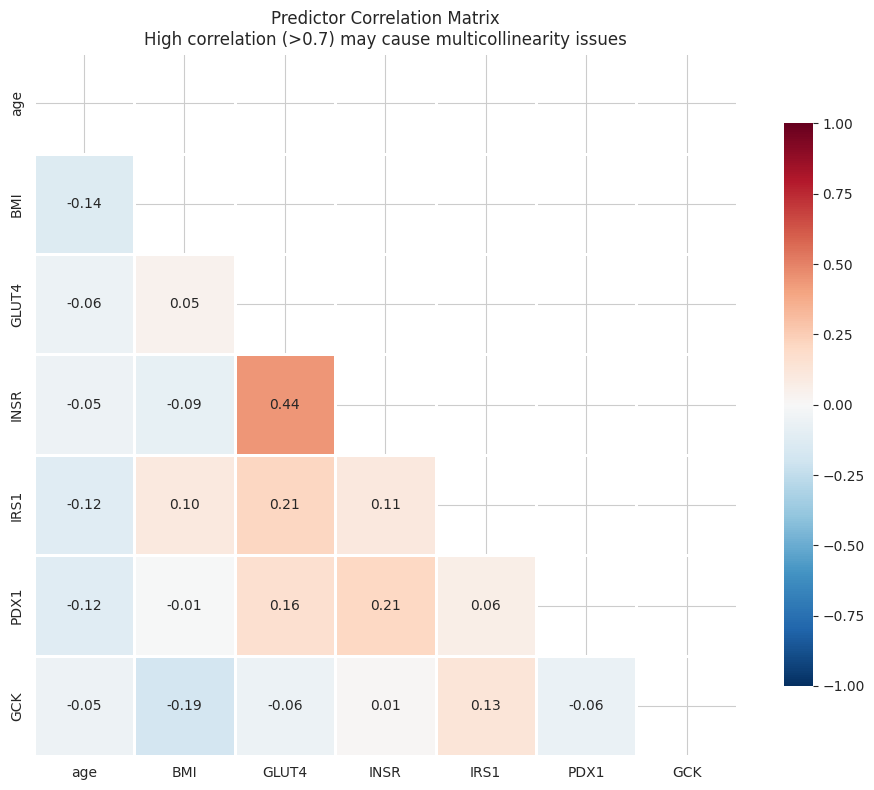

In [ ]:
# Visualize correlations
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(cor_matrix, dtype=bool))
sns.heatmap(cor_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
           center=0, vmin=-1, vmax=1, square=True, linewidths=1,
           cbar_kws={"shrink": 0.8})
plt.title('Predictor Correlation Matrix\nHigh correlation (>0.7) may cause multicollinearity issues')
plt.tight_layout()
plt.show()

**What to look for**:
- **High correlation (>0.7)**: Consider removing one predictor
- **Why?** Correlated predictors provide redundant information
- Makes coefficient interpretation difficult

**Step 4: Fit initial model with all predictors**

In [ ]:
# Full model
model_full = ols('fasting_glucose ~ age + BMI + GLUT4 + INSR + IRS1 + PDX1 + GCK',
                data=full_data).fit()

print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:        fasting_glucose   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.199
Method:                 Least Squares   F-statistic:                     4.512
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           0.000232
Time:                        19:54:34   Log-Likelihood:                -408.08
No. Observations:                 100   AIC:                             832.2
Df Residuals:                      92   BIC:                             853.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    217.1674     28.880      7.520      0.0

**Step 5: Remove non-significant predictors**

If some predictors have p > 0.05, consider removing them (if they're not theoretically important).

In [ ]:
# Reduced model (remove non-significant predictors)
# Example: if GCK and age were not significant
model_reduced = ols('fasting_glucose ~ BMI + GLUT4 + INSR + IRS1 + PDX1',
                   data=full_data).fit()

# Compare models using ANOVA
anova_results = sm.stats.anova_lm(model_reduced, model_full)
print("\nModel Comparison (ANOVA):")
print(anova_results)


Model Comparison (ANOVA):
   df_resid           ssr  df_diff    ss_diff         F    Pr(>F)
0      94.0  20601.570875      0.0        NaN       NaN       NaN
1      92.0  20516.619848      2.0  84.951027  0.190467  0.826898


**Interpretation**:
- If p > 0.05: Removed predictors don't significantly improve fit → use simpler model
- If p < 0.05: Keep the full model

**Final decision**:
- Balance **statistical significance** with **biological importance**
- Sometimes keep a predictor even if p > 0.05 if it's biologically crucial

---

## Part 12: Key Concepts Summary

### Linear Model vs Logistic Regression Decision Tree

```
Is your outcome continuous (can take any numeric value)?
│
├─ YES → Use Linear Model
│         Examples: gene expression, tumor size, glucose level
│         Python: from statsmodels.formula.api import ols
│                 model = ols('outcome ~ predictors', data=df).fit()
│
└─ NO → Is it binary (yes/no, 0/1)?
          │
          ├─ YES → Use Logistic Regression
          │         Examples: disease status, drug response
          │         Python: from statsmodels.formula.api import logit
          │                 model = logit('outcome ~ predictors', data=df).fit()
          │
          └─ NO → Other specialized models (Poisson, etc.)
```

---

### Common Pitfalls and How to Avoid Them

| Pitfall | Problem | Solution |
|---------|---------|----------|
| **Too many predictors** | Overfitting, model memorizes noise | Use domain knowledge to select relevant predictors |
| **Correlated predictors** | Unstable coefficients, hard to interpret | Check correlation matrix, remove redundant predictors |
| **Small sample size** | Unreliable estimates | Rule of thumb: >10-15 samples per predictor |
| **Not checking assumptions** | Invalid inferences | Always plot diagnostics (residuals, Q-Q plot) |
| **Ignoring biological meaning** | Statistically significant but meaningless | Always interpret in biological context |
| **Using Linear Model for binary outcome** | Predictions outside 0-1 range | Use Logistic Regression instead |
| **Not visualizing first** | Missing obvious patterns or issues | Always plot data before modeling |

---

### When to Use Each Approach

**Use Supervised Learning when**:
- ✅ You have a clear outcome to predict
- ✅ You want to understand predictor importance
- ✅ You need to make predictions on new samples
- ✅ You want to test specific hypotheses about relationships

**Use Unsupervised Learning (Chapter 8) when**:
- ✅ Exploring data structure without predefined outcome
- ✅ Finding natural groupings in data
- ✅ Reducing dimensionality for visualization
- ✅ Discovering unexpected patterns

**Often, you'll use both**:
1. Start with unsupervised methods (PCA, clustering) to explore
2. Use insights to guide supervised modeling
3. Build predictive models for specific outcomes

---

## 🎯 Chapter Summary

**What we learned**:

1. **Supervised vs Unsupervised Learning**
   - Supervised: predict known outcomes
   - Unsupervised: explore patterns without labels

2. **Linear Models**
   - For continuous outcomes
   - Coefficients show relationship strength
   - Check assumptions with diagnostic plots

3. **Logistic Regression**
   - For binary outcomes (disease/healthy)
   - Predict probabilities and classify
   - Interpret via odds ratios and probabilities

4. **Model Comparison**
   - AIC for model selection (lower is better)
   - ROC curves and AUC for classification performance
   - Statistical tests to compare models

5. **Interaction Effects**
   - When predictor effects depend on other variables
   - Test with interaction terms (X1 * X2)
   - Visualize with stratified plots

6. **Variable Selection**
   - Use biological knowledge first
   - Check for multicollinearity
   - Balance complexity with interpretability

**Key Python libraries**:
- `statsmodels`: Statistical models (ols, logit)
- `sklearn`: Machine learning tools (ROC, metrics)
- `pandas`: Data manipulation
- `matplotlib/seaborn`: Visualization

---

## 💪 Practice Exercises

### Exercise 1: Build Your Own Linear Model

**Task**: Predict BMI from gene expression

**Starter code**:

In [ ]:
# Exercise 1: Predict BMI from gene expression
# Your code here

# Step 1: Fit a linear model predicting BMI from GLUT4 and INSR
# Hint: model_bmi = ols('BMI ~ GLUT4 + INSR', data=full_data).fit()

# Step 2: Check the summary
# Hint: print(model_bmi.summary())

# Step 3: Visualize the relationship between predicted and actual BMI
# Hint: Add predicted values to data, then plot

# Step 4: Check diagnostic plots
# Hint: Create residual plots

# Questions to answer:
# - Are GLUT4 and INSR significant predictors of BMI?
# - What percentage of BMI variance is explained (R²)?
# - Do the model assumptions appear to be met?

### Exercise 2: Logistic Regression with Different Predictors

**Task**: Can age and fasting glucose alone predict diabetes?

**Starter code**:

In [ ]:
# Exercise 2: Predict diabetes from age and fasting glucose
# Your code here

# Step 1: Fit logistic regression model
# Hint: model_age_glucose = logit('diabetes ~ age + fasting_glucose', data=full_data).fit()

# Step 2: Create ROC curve and calculate AUC
# Hint: Use roc_curve and roc_auc_score from sklearn.metrics

# Step 3: Create confusion matrix
# Hint: First predict probabilities, then classify using 0.5 threshold

# Step 4: Compare this model to the combined model
# Hint: Compare AIC values

# Questions to answer:
# - What is the AUC of this model?
# - How does it compare to the combined model (clinical + genomic)?
# - Do genes add value beyond age and glucose?

### Exercise 3: Test for Interaction Effects

**Task**: Does the effect of INSR on glucose depend on BMI?

**Starter code**:

In [ ]:
# Exercise 3: Test for interaction between INSR and BMI
# Your code here

# Step 1: Fit model WITHOUT interaction
# Hint: model_no_int = ols('fasting_glucose ~ INSR + BMI', data=full_data).fit()

# Step 2: Fit model WITH interaction
# Hint: model_int = ols('fasting_glucose ~ INSR * BMI', data=full_data).fit()

# Step 3: Compare models with ANOVA
# Hint: sm.stats.anova_lm(model_no_int, model_int)

# Step 4: Visualize the interaction
# Hint: Create BMI groups and plot INSR vs glucose for each group

# Questions to answer:
# - Is the interaction term significant?
# - Does INSR have different effects in high vs low BMI patients?
# - What is the biological interpretation?

### Exercise 4: Variable Importance Analysis

**Task**: Which predictor is most important for predicting diabetes?

**Starter code**:

In [ ]:
# Exercise 4: Rank predictor importance
# Your code here

# Step 1: Standardize all predictors (mean=0, SD=1)
# Hint: Use StandardScaler from sklearn

# Step 2: Fit logistic regression with standardized predictors
# Hint: Include BMI, age, GLUT4, INSR, IRS1

# Step 3: Extract and compare absolute coefficient values
# Hint: Create a DataFrame with coefficients and p-values

# Step 4: Create a visualization ranking predictors by importance
# Hint: Bar plot with absolute standardized coefficients

# Questions to answer:
# - Which predictor has the largest effect?
# - Are genomic or clinical predictors more important?
# - Which predictors are not significant?

### Exercise 5: Model Building Challenge

**Scenario**: You're consulting for a clinical lab. They can measure either:
- **Option A**: All 5 genes (expensive, $500 per test)
- **Option B**: Only clinical variables (cheap, $50 per test)

**Your task**: Determine if gene testing is worth the extra cost.

**Starter code**:

In [ ]:
# Exercise 5: Clinical vs Genomic Decision
# Your code here

# Step 1: Build clinical-only model
# Hint: Use BMI, age, fasting_glucose

# Step 2: Build genomic-enhanced model
# Hint: Add GLUT4, INSR, IRS1 to clinical variables

# Step 3: Compare performance metrics
# Hint: Calculate AUC, accuracy, sensitivity, specificity for both

# Step 4: Visualize both ROC curves on same plot
# Hint: Plot multiple ROC curves together

# Step 5: Statistical test for difference in AUCs
# Hint: Use the delong_test function from earlier

# Questions to answer:
# - How much does genomic testing improve AUC?
# - Is the improvement statistically significant?
# - What would you recommend to the lab director?

---

## 🔗 Connection to Other Chapters

**Chapter 4 (Differential Expression)** → **Chapter 9**
- Use DEGs as candidate predictors in supervised models
- Genes significantly different between groups are good candidates

**Chapter 8 (PCA/Clustering)** → **Chapter 9**
- Use PCs as predictors to reduce dimensionality
- Cluster membership can be a predictor

**Chapter 9** → **Future Machine Learning**
- Logistic Regression is the foundation for more complex methods
- Regularization (LASSO, Ridge) builds on these concepts
- Random forests, neural networks extend these ideas

---

## 📚 Additional Resources

**Books**:
- *An Introduction to Statistical Learning* by James et al. (free online, also has Python version)
- *Python for Data Analysis* by Wes McKinney
- *Hands-On Machine Learning* by Aurélien Géron

**Python Documentation**:
- `statsmodels`: https://www.statsmodels.org/
- `scikit-learn`: https://scikit-learn.org/
- `pandas`: https://pandas.pydata.org/

**Online Tutorials**:
- StatQuest (YouTube) - excellent visual explanations
- Kaggle Learn - hands-on ML tutorials
- scikit-learn tutorials - comprehensive ML guide

---

## 🎓 Learning Outcomes Check

After completing this chapter, you should be able to:

- [ ] Distinguish between supervised and unsupervised learning
- [ ] Choose between Linear Models and Logistic Regression based on outcome type
- [ ] Interpret coefficients and p-values from regression models
- [ ] Check model assumptions using diagnostic plots
- [ ] Compare models using AIC and ROC curves
- [ ] Test and interpret interaction effects
- [ ] Assess variable importance in predictive models
- [ ] Make predictions and evaluate model performance
- [ ] Select appropriate predictors using biological knowledge
- [ ] Communicate modeling results clearly

**If you can't check all boxes, review the relevant sections!**

---

**End of Chapter 9** 🎉

---

## 💾 Save Your Work

To save this notebook to your Google Drive:
1. Click **File → Save a copy in Drive**
2. Your work will be saved in Google Drive > Colab Notebooks

To download as .ipynb:
1. Click **File → Download → Download .ipynb**